<!-- CURRICULUM_HEADER_START -->
<div class="mh"><p class="mh-crumb"><a href="/series/forecasting/index.html">Forecasting with Machine Learning</a><span class="sep">·</span>Part 2 · Features</p><p class="mh-facts"><span class="lvl lvl-intermediate">Intermediate</span></p><p class="mh-assumes">Assumes <span class="unwritten" title="not written yet">Horizon, frequency and target</span> and <span class="unwritten" title="not written yet">Leakage</span>.</p></div>
<!-- CURRICULUM_HEADER_END -->

::: {.callout-note appearance="simple" icon=false}
## TL;DR

A tree model cannot see that week 51 sits next to week 0, that last year's berry weight is the best first guess for this week's, or that a lag must never cross from one field into the next. This module builds those signals for a weekly berry-weight series with `feature_engine`'s `CyclicalFeatures`, `OrdinalEncoder`, `LagFeatures` and `WindowFeatures` inside two scikit-learn `Pipeline` objects. You leave with a 38-column feature table that regenerates from raw data in one `transform()` call.
:::

Raw tabular data rarely gives a model the right context for time series forecasting. The dataset here is three years of weekly berry weights for five vineyard fields; the pipeline enriches it with cyclical encodings, lag features and rolling windows from [`feature_engine`](https://feature-engine.trainindata.com/).

In [1]:
import pandas as pd
import numpy as np
from datetime import date, timedelta
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from feature_engine.creation import CyclicalFeatures
from feature_engine.encoding import OrdinalEncoder
from feature_engine.timeseries.forecasting import LagFeatures, WindowFeatures
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## The dataset

We simulate three years of weekly observations for five vineyard fields (three grape varieties). Each row represents one field on one Saturday: measured berry weight plus five weather readings.

In [2]:
np.random.seed(42)

WEATHER_COLS = [
    "temp_mean_c",
    "rainfall_mm",
    "solar_rad_wm2",
    "humidity_pct",
    "wind_speed_ms",
]
FIELDS = ["F01", "F02", "F03", "F04", "F05"]
VARIETIES = {
    "F01": "Chardonnay",
    "F02": "Chardonnay",
    "F03": "Pinot Noir",
    "F04": "Merlot",
    "F05": "Merlot",
}

today = date(2026, 3, 14)
last_saturday = today - timedelta(days=(today.weekday() + 2) % 7)
start_date = last_saturday - timedelta(weeks=3 * 52 - 1)
weekly_dates = [start_date + timedelta(weeks=i) for i in range(3 * 52)]


def pruning_week(d):
    woy = (d - date(d.year, 1, 1)).days // 7
    return woy - 8 if woy >= 8 else woy + 52 - 8


def biological_weight_curve(weeks_since_pruning, variety):
    base = {"Chardonnay": 1.8, "Pinot Noir": 1.4, "Merlot": 2.2}[variety]
    w = weeks_since_pruning % 52
    return max(
        0.1,
        base * (1 / (1 + np.exp(-0.3 * (w - 14)))) * (1 - 0.3 * max(0, w - 22) / 30),
    )


records = []
for field in FIELDS:
    variety = VARIETIES[field]
    field_effect = np.random.normal(0, 0.1)
    for d in weekly_dates:
        wsp = pruning_week(d)
        woy = (d - date(d.year, 1, 1)).days // 7
        base_w = biological_weight_curve(wsp, variety)
        temp_mean = 15 + 10 * np.sin(2 * np.pi * woy / 52) + np.random.normal(0, 2)
        rainfall = max(
            0, np.random.exponential(8) * (1 - 0.5 * np.sin(2 * np.pi * woy / 52))
        )
        solar_rad = (
            180 + 120 * np.sin(2 * np.pi * (woy - 13) / 52) + np.random.normal(0, 20)
        )
        humidity = 60 + 15 * np.cos(2 * np.pi * woy / 52) + np.random.normal(0, 5)
        wind_speed = max(0, np.random.exponential(3))
        weather_eff = (
            0.04 * (temp_mean - 15)
            - 0.005 * rainfall
            + 0.001 * solar_rad
            - 0.002 * humidity
            + np.random.normal(0, 0.08)
        )
        records.append(
            {
                "date": d,
                "field_id": field,
                "variety": variety,
                "berry_weight_g": round(
                    max(0.05, base_w + field_effect + weather_eff), 3
                ),
                "week_of_year": woy,
                "weeks_since_pruning": wsp,
                "temp_mean_c": round(temp_mean, 1),
                "rainfall_mm": round(max(0, rainfall), 1),
                "solar_rad_wm2": round(solar_rad, 1),
                "humidity_pct": round(float(np.clip(humidity, 20, 100)), 1),
                "wind_speed_ms": round(wind_speed, 2),
            }
        )

df = pd.DataFrame(records).sort_values(["field_id", "date"]).reset_index(drop=True)
print(f"Shape: {df.shape}")
df[
    ["date", "field_id", "variety", "berry_weight_g", "week_of_year", "temp_mean_c"]
].head(8)

Shape: (780, 11)


,date,field_id,variety,berry_weight_g,week_of_year,temp_mean_c
0,2023-03-25,F01,Chardonnay,0.625,11,24.4
1,2023-04-01,F01,Chardonnay,0.663,12,26.5
2,2023-04-08,F01,Chardonnay,0.418,13,21.2
3,2023-04-15,F01,Chardonnay,0.487,14,22.1
4,2023-04-22,F01,Chardonnay,0.650,15,24.9
5,2023-04-29,F01,Chardonnay,0.993,16,28.1
6,2023-05-06,F01,Chardonnay,0.859,17,21.4
7,2023-05-13,F01,Chardonnay,0.911,18,23.6


## Encodings

Two kinds of column need translating before a tree model can use them: `week_of_year`, which is periodic, and the string labels for variety and field.

### Cyclical encoding for periodic variables

`week_of_year` runs from 0 to 51 — but week 51 and week 0 are *neighbours* on the calendar. A raw integer encoding treats them as maximally distant (51 − 0 = 51). **Cyclical encoding** maps them onto a unit circle via sine and cosine, so the model sees their true proximity.

$$\text{sin} = \sin\!\left(\frac{2\pi \cdot x}{\text{period}}\right), \quad \text{cos} = \cos\!\left(\frac{2\pi \cdot x}{\text{period}}\right)$$

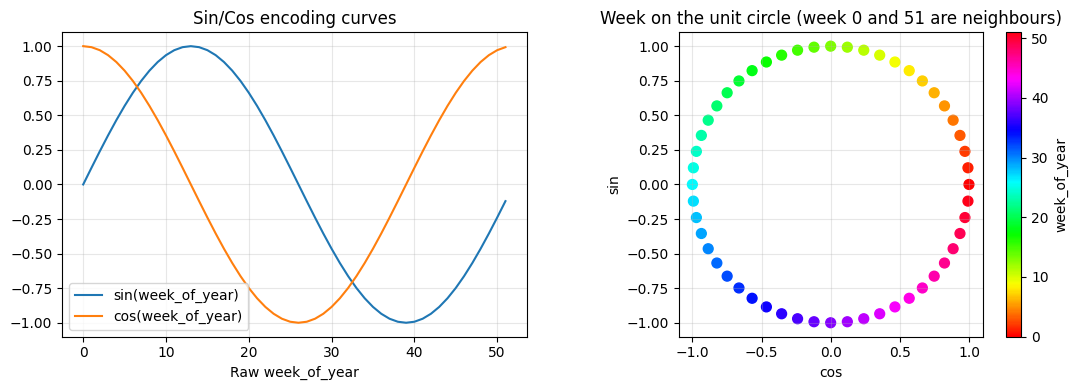

In [3]:
weeks = np.arange(52)
sin_enc = np.sin(2 * np.pi * weeks / 52)
cos_enc = np.cos(2 * np.pi * weeks / 52)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(weeks, sin_enc, label="sin(week_of_year)")
axes[0].plot(weeks, cos_enc, label="cos(week_of_year)")
axes[0].set_xlabel("Raw week_of_year")
axes[0].set_title("Sin/Cos encoding curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(cos_enc, sin_enc, c=weeks, cmap="hsv", s=50)
plt.colorbar(sc, ax=axes[1], label="week_of_year")
axes[1].set_aspect("equal")
axes[1].set_xlabel("cos")
axes[1].set_ylabel("sin")
axes[1].set_title("Week on the unit circle (week 0 and 51 are neighbours)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Ordinal encoding for categorical variables

Tree-based models need numbers, not strings. `OrdinalEncoder` maps each category to an integer. Combined with the cyclical encoder in a `Pipeline`, both transformations apply in one `fit_transform` call.

In [4]:
global_fe_pipeline = Pipeline(
    [
        (
            "cyclical",
            CyclicalFeatures(
                variables=["week_of_year", "weeks_since_pruning"], drop_original=False
            ),
        ),
        (
            "encoding",
            OrdinalEncoder(
                encoding_method="arbitrary", variables=["variety", "field_id"]
            ),
        ),
    ]
)

df_global = global_fe_pipeline.fit_transform(df)

enc = global_fe_pipeline.named_steps["encoding"]
print("Variety encoding:", enc.encoder_dict_["variety"])
df_global[
    [
        "date",
        "field_id",
        "variety",
        "week_of_year",
        "week_of_year_sin",
        "week_of_year_cos",
    ]
].head(6)

Variety encoding: {'Chardonnay': 0, 'Pinot Noir': 1, 'Merlot': 2}


,date,field_id,variety,week_of_year,week_of_year_sin,week_of_year_cos
0,2023-03-25,0,0,11,0.976848,0.213933
1,2023-04-01,0,0,12,0.995734,0.092268
2,2023-04-08,0,0,13,0.999526,-0.030795
3,2023-04-15,0,0,14,0.988165,-0.153392
4,2023-04-22,0,0,15,0.961826,-0.273663
5,2023-04-29,0,0,16,0.920906,-0.389786


## Lags, windows and the full pipeline

### Lag features and rolling windows

**Lag features** expose past values as predictors: `temp_mean_c_lag_1` is last week's temperature; `berry_weight_g_lag_52` is the weight measured exactly one year ago (a strong seasonal baseline).

**Window features** smooth out noise: `temp_mean_c_window_4_mean` is the 4-week rolling average.

Both must be computed *per field* — lags should not bleed across vineyards.

> **Gap-filling caveat**: `LagFeatures` counts rows, not calendar weeks. A missing Saturday would shift a lag_52 onto the wrong date. We reindex each field to a complete weekly grid before computing transforms, then drop the filler rows.

In [5]:
# Demo: LagFeatures + WindowFeatures on a single field (F01)
f01 = (
    df[df["field_id"] == "F01"]
    .sort_values("date")
    .head(12)[["date", "temp_mean_c", "berry_weight_g"]]
    .reset_index(drop=True)
)

lf_demo = LagFeatures(
    variables=["temp_mean_c", "berry_weight_g"], periods=[1, 2], sort_index=False
)
wf_demo = WindowFeatures(
    variables=["temp_mean_c"], functions=["mean"], window=4, sort_index=False
)

f01_demo = wf_demo.fit_transform(lf_demo.fit_transform(f01.copy()))
f01_demo[
    [
        "date",
        "temp_mean_c",
        "temp_mean_c_lag_1",
        "temp_mean_c_lag_2",
        "temp_mean_c_window_4_mean",
        "berry_weight_g",
        "berry_weight_g_lag_1",
    ]
]

,date,temp_mean_c,temp_mean_c_lag_1,temp_mean_c_lag_2,temp_mean_c_window_4_mean,berry_weight_g,berry_weight_g_lag_1
0,2023-03-25,24.4,NaN,NaN,NaN,0.625,NaN
1,2023-04-01,26.5,24.4,NaN,NaN,0.663,0.625
2,2023-04-08,21.2,26.5,24.4,NaN,0.418,0.663
3,2023-04-15,22.1,21.2,26.5,NaN,0.487,0.418
4,2023-04-22,24.9,22.1,21.2,23.550,0.650,0.487
5,2023-04-29,28.1,24.9,22.1,23.675,0.993,0.650
6,2023-05-06,21.4,28.1,24.9,24.075,0.859,0.993
7,2023-05-13,23.6,21.4,28.1,24.125,0.911,0.859
8,2023-05-20,24.6,23.6,21.4,24.500,1.027,0.911
9,2023-05-27,22.9,24.6,23.6,24.425,1.109,1.027


### The full pipeline

We chain gap-filling, per-field lag/window computation, and a log-transform of the 52-week lagged target into a second `Pipeline`. This keeps all transformations stateless and reproducible — safe to call `transform()` on new data without re-fitting.

In [6]:
def _fill_weekly_gaps(X):
    """Reindex each field to a gapless weekly Saturday grid."""
    pieces = []
    for field, grp in X.groupby("field_id"):
        grp = grp.set_index("date").sort_index()
        full_idx = pd.date_range(grp.index.min(), grp.index.max(), freq="W-SAT")
        grp = grp.reindex(full_idx)
        grp["date"] = full_idx.date
        grp["field_id"] = field
        grp["_is_gap"] = grp["berry_weight_g"].isna()
        pieces.append(grp.reset_index(drop=True))
    return pd.concat(pieces).sort_values(["field_id", "date"]).reset_index(drop=True)


def _apply_grouped_ts_features(X):
    """Compute weather lags (1-3 wk), target lags (1, 52 wk), and 4-wk rolling means per field."""
    weather_lags = LagFeatures(
        variables=WEATHER_COLS, periods=[1, 2, 3], sort_index=False
    )
    target_lags = LagFeatures(
        variables=["berry_weight_g"], periods=[1, 52], sort_index=False
    )
    weather_wins = WindowFeatures(
        variables=WEATHER_COLS, functions=["mean"], window=4, sort_index=False
    )
    groups = []
    for _, grp in X.groupby("field_id"):
        g = grp.copy()
        g = weather_lags.fit_transform(g)
        g = target_lags.fit_transform(g)
        g = weather_wins.fit_transform(g)
        groups.append(g)
    result = pd.concat(groups).sort_index()
    return result[~result["_is_gap"]].drop(columns="_is_gap").reset_index(drop=True)


def _add_log_lag52(X):
    X = X.copy()
    X["log_weight_lag52"] = np.log(X["berry_weight_g_lag_52"].clip(lower=0.01))
    return X


grouped_fe_pipeline = Pipeline(
    [
        ("gap_check", FunctionTransformer(_fill_weekly_gaps)),
        ("ts_features", FunctionTransformer(_apply_grouped_ts_features)),
        ("log_lag52", FunctionTransformer(_add_log_lag52)),
    ]
)

df_transformed = grouped_fe_pipeline.fit_transform(df_global)
print(f"Final shape: {df_transformed.shape}  ({df_transformed.shape[1]} features)")
new_cols = [c for c in df_transformed.columns if c not in df.columns]
print(f"\nNew columns added ({len(new_cols)}):")
for c in new_cols:
    print(f"  {c}")

Final shape: (780, 38)  (38 features)

New columns added (27):
  week_of_year_sin
  week_of_year_cos
  weeks_since_pruning_sin
  weeks_since_pruning_cos
  temp_mean_c_lag_1
  rainfall_mm_lag_1
  solar_rad_wm2_lag_1
  humidity_pct_lag_1
  wind_speed_ms_lag_1
  temp_mean_c_lag_2
  rainfall_mm_lag_2
  solar_rad_wm2_lag_2
  humidity_pct_lag_2
  wind_speed_ms_lag_2
  temp_mean_c_lag_3
  rainfall_mm_lag_3
  solar_rad_wm2_lag_3
  humidity_pct_lag_3
  wind_speed_ms_lag_3
  berry_weight_g_lag_1
  berry_weight_g_lag_52
  temp_mean_c_window_4_mean
  rainfall_mm_window_4_mean
  solar_rad_wm2_window_4_mean
  humidity_pct_window_4_mean
  wind_speed_ms_window_4_mean
  log_weight_lag52


## Key takeaways

| Transform | Class | What it adds |
|-----------|-------|--------------|
| Cyclical encoding | `CyclicalFeatures` | sin/cos of week_of_year, weeks_since_pruning |
| Categorical encoding | `OrdinalEncoder` | integer codes for variety and field_id |
| Lag features | `LagFeatures` | past values (1–3 week weather, 1 & 52 week target) |
| Rolling windows | `WindowFeatures` | 4-week rolling mean of weather variables |

- Sine and cosine of a periodic variable put week 51 next to week 0; a raw integer puts them 51 apart.
- `OrdinalEncoder` is stateful — it must see every category at fit time — so it lives in its own pipeline, separate from the stateless lag and window steps.
- Lags and rolling windows are computed per field, so no value bleeds from one vineyard into another.
- `LagFeatures` counts rows, not weeks; reindex to a gapless weekly grid first or a missing Saturday shifts lag_52 onto the wrong date.
- The lag and window pipeline is stateless, so `transform()` is safe on any future data window. The next module trains an ensemble on these features.

<!-- CURRICULUM_FOOTER_START -->
<div class="mf"><a class="mf-up" href="/series/forecasting/index.html"><span>Series</span>Forecasting with Machine Learning</a><a class="mf-next" href="/blogs/forecast/2_ensemble_models.html"><span>Next</span>Ensemble models</a></div>
<!-- CURRICULUM_FOOTER_END -->